# Tugas 4: Klasifikasi Teks Berita Menggunakan Word Embedding Skip-gram (Co-occurrence Matrix + SVD), Naive Bayes, dan k-Nearest Neighbors (kNN)

Pada tugas ini, kita memproses **200 artikel berita mentah** dari Detik.com (100 berita kategori *Sport* dan 100 berita kategori *Finance*).

Skenario pemodelan mengadaptasi konsep Word Embedding berbasis pasangan konteks Skip-gram tanpa menggunakan arsitektur jaringan syaraf tiruan (Artificial Neural Network / ANN):
- Setiap artikel berita diperlakukan sebagai **representasi kalimat panjang/dokumen** yang memuat kata-kata informatif.
- Kata-kata di dalam artikel berita digunakan untuk membentuk jendela konteks (*context window*) model **Skip-gram**.
- Pasangan *(Target, Context)* dari jendela konteks dihimpun ke dalam **Matriks Ko-okurensi Kata (*Word Co-occurrence Matrix*)** berukuran $V \times V$.
- Dimensi matriks ko-okurensi direduksi ke dimensi laten $N$ yang fleksibel menggunakan **Singular Value Decomposition (SVD)** untuk menghasilkan matriks representasi kata (*Word Embedding*).
- Setiap dokumen direpresentasikan menjadi vektor kontinu berdimensi $N$ melalui metode **Average Pooling (Mean Word Vector)** dari kata-kata penyusunnya.
- Vektor dokumen berita kemudian diklasifikasikan menggunakan dua algoritma machine learning:
  1. **Gaussian Naive Bayes (`GaussianNB`)** (pendekatan probabilistik distribusi gaussian).
  2. **k-Nearest Neighbors (`KNeighborsClassifier`)** (pendekatan jarak euclidean ruang metrik vektor).
- Eksperimen menguji dan membandingkan secara komprehensif dua kondisi pra-pemrosesan:
  1. **Skenario 1**: **Tanpa Membuang Stopword** (*With Stopwords / Raw Tokens*).
  2. **Skenario 2**: **Membuang Stopword** (*Stopwords Removed* menggunakan pustaka *Sastrawi*).

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from collections import Counter

# Modul NLP Sastrawi untuk Stopwords Bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Modul Reduksi Dimensi SVD & Klasifikasi (Naive Bayes & kNN)
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Styling visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

print("Seluruh pustaka pendukung (termasuk Naive Bayes & kNN) berhasil dimuat!")

Seluruh pustaka pendukung (termasuk Naive Bayes & kNN) berhasil dimuat!


## 1. Konfigurasi Parameter & Pemuatan Data Berita Mentah

Kita menyediakan variabel konfigurasi terpusat agar parameter model (seperti dimensi embedding, ukuran vocabulary, dan ukuran jendela) dapat **diotak-atik secara fleksibel**:

- `EMBEDDING_DIM`: Dimensi ruang vektor embedding hasil reduksi SVD ($N$).
- `WINDOW_SIZE`: Jarak jangkauan konteks ke kiri dan kanan ($C$).
- `TOP_VOCAB`: Jumlah kosakata teratas yang diseleksi agar fokus pada kata-kata informatif ($V$).
- `TEST_SIZE`: Proporsi data uji untuk evaluasi model Naive Bayes.

In [2]:
# =============================================================================
# PARAMETER YANG BISA DIOTAK-ATIK SECARA FLEKSIBEL:
# =============================================================================
EMBEDDING_DIM = 12       # Dimensi vektor embedding SVD (misal: 4, 8, 12, 16, 32)
WINDOW_SIZE = 10         # Lebar jendela konteks sliding window (misal: 2, 3, 5)
TOP_VOCAB = 150         # Ukuran vocabulary teratas per skenario
TEST_SIZE = 0.25        # Proporsi data uji (25% = 50 dokumen uji)
RANDOM_STATE = 42       # Seed reproducibility
# =============================================================================

# Membaca dataset 200 berita mentah detik.com
csv_path = "dataset_berita_detik.csv"
df = pd.read_csv(csv_path)

print(f"Bentuk Dataset Berita: {df.shape[0]} baris dokumen, {df.shape[1]} kolom.")
print("\nDistribusi Kategori Label Berita:")
print(df['label'].value_counts())

print("\nContoh 3 Sampel Data Teratas:")
display(df.head(3))

Bentuk Dataset Berita: 200 baris dokumen, 3 kolom.

Distribusi Kategori Label Berita:
label
Sport      100
Finance    100
Name: count, dtype: int64

Contoh 3 Sampel Data Teratas:


,ID,Isi berita,label
0,1,"Persatuan Bulutangkis Indonesia (PBSI) baru saja mengumumkan daftar 20 pemain yang dibawa ke Asian Games 2026. Jonatan Christie salah satunya. Dari daftar 20 nama itu dibagi rata, yakni 10 pebulutangkis putra dan 10 pebulutangkis putri. Keputusan ini diambil setelah melalui evaluasi yang mendalam selama beberapa bulan. Beberapa aspek yang dinilai adalah performa terkini, kondisi fisik, hingga kebutuhan teknis tim, sebelum nama-nama pemain dipilih. ""Penetapan skuad itu dilakukan setelah melalui proses evaluasi secara menyeluruh. Kami melihat performa, kondisi fisik dan teknis masing-masing pemain, serta kebutuhan tim untuk menentukan komposisi yang paling sesuai dengan target di Asian Games,"" ujar Kepala Bidang Pembinaan dan Prestasi PBSI, Eng Hian, dalam keterangan resminya. Meski membawa 20 nama ke Asian Games Aichi-Nagoya 2026, ada beberapa nama yang memang tidak akan tampil di nomor perorangan. Mereka lebih difokuskan untuk menambah kedalaman skuad di nomor beregu. Di nomor perorangan, Jonatan Christie dan Alwi Farhan akan menjadi tumpuan. Sementara di nomor beregu, Moh Zaki Ubaidillah dan Muhamad Yusuf jad tumpuan. Hal serupa dilakukan untuk tim putri, baik di sektor perorangan maupun beregu. Asian Games 2026 berlangsung 19 September hingga 4 Oktober, di mana cabor bulutangkis dimulai sehari setelah upacara pembukaan. Nomor beregu lebih dulu dipertandingkan mulai 20 hingga 24 September, sebelum nomor perorangan dari 25 hingga 29 September. Cabor bulutangkis digelar di Ichinomiya City Municipal Gymnasium. ""Jadi, fokus utama kami adalah nomor beregu terlebih dahulu. Kami ingin seluruh pemain bisa tampil maksimal dan memberikan kontribusi terbaik untuk tim putra maupun putri,"" sambung Eng Hian. Daftar Pebulutangkis putra Jonatan Christie Alwi Farhan Moh Zaki Ubaidillah Muhamad Yusuf Fajar Alfian Muhammad Shohibul Fikri Leo Rolly Carnando Daniel Marthin Nikolaus Joaquin Amri Syahnawi Daftar Pebulutangkis putri Putri Kusuma Wardani Thalita Ramadhani Wiryawan Ni Kadek Dhinda Amartya Pratiwi Mutiara Ayu Puspitasari Rachel Allessya Rose Febi Setianingrum Febriana Dwipuji Kusuma Meilysa Trias Puspitasari Siti Fadia Silva Ramadhanti Nita Violina Marwah (mrp/aff)",Sport
1,2,"Tunggal putra Indonesia, Jonatan Christie, menelan kekalahan di ajang China Masters. Pada babak kedua, Jojo dikalahkan Jason Gunawan 16-21 dan 16-21. Di Arena Shenzhen, Shenzhen, Kamis (3/9/2026) pagi WIB, Jojo menjalani pertandingan selama 45 menit melawan Jason. Pertarungan gim pertama berjalan sengit dan imbang sampai 14-14. Setelah itu, Jason tak terkejar. Pemain asal Hong Kong itu akhirnya menyudahi perjuangan Jojo dengan skor 21-16. Pada gim kedua, Jojo juga menjalani pertarungan sengit melawan Jason. Skor imbang antara Jojo dan Jason bertahan sampai 13-13. Saat fase krusial, Jason kembali tampil lebih prima untuk merebut kemenangan 21-16. Dengan hasil ini, wakil Indonesia di nomor tunggal putra China Masters pun habis. Indonesia masih mempunyai beberapa wakil di nomor ganda putra. Sabar Karyaman Gutama/Muhammad Reza Pahlevi Isfahani, Ali Faathir Rayhan/Devin Artha Wahyudi, dan Leo Rolly Carnando/Daniel Marthin merupakan deretan pemain Indonesia yang masih berjuang. (cas/krs)",Sport
2,3,"Sabar Karyaman Gutama/Moh Reza Pahlevi Isfahani lolos ke babak 16 besar China Masters 2026. Mereka menyingkirkan wakil Korea, Kang Min Hyuk/Ki Dong Ju, lewat kemenangan straight game. Sabar/Reza menghadapi Kang/Ki di Shenzhen Arena, Guangdong, Rabu (2/9/2026) sore WIB. Mereka butuh waktu 43 menit untuk menyudahi perlawanan Kang/Ki 21-18, 21-16. Pertandingan berjalan ketat sejak awal gim pertama. Sabar/Reza hanya unggul 11-10 atas Kang/Ki saat interval. Selepas interval, Kang/Ki berbalik unggul dan Sabar/Reza lebih banyak dalam posisi mengejar. Dalam posisi tertinggal 14-16, Sabar/Reza merebut tiga angka beruntun untuk menyalip. Meski Kang/Ki bisa menyamakan kedudukan 18-18, Sabar/Reza lebih tenang di poin-poin krusial. Mereka merebut tiga angka

## 2. Pra-pemrosesan Teks: Komparasi Korpus Dengan Stopword vs Tanpa Stopwords

Setiap isi berita dibersihkan dengan tahap:
1. **Case Folding**: Mengubah seluruh teks menjadi huruf kecil (*lowercase*).
2. **Pembersihan Karakter Non-Alfabet**: Menghilangkan tanda baca, simbol angka, dan karakter khusus.
3. **Tokenisasi**: Memecah string berita menjadi token kata dengan panjang $> 2$ huruf.

Kemudian dibangun dua korpus:
- **Korpus A (Dengan Stopwords)**: Mempertahankan seluruh token kata apa adanya (termasuk kata sambung/hubung seperti *yang, di, dan, untuk, ini, itu*).
- **Korpus B (Tanpa Stopwords)**: Menyaring dan membuang seluruh kata yang termasuk dalam daftar stopwords Bahasa Indonesia dari *Sastrawi*.

In [3]:
# Ambil daftar stopwords resmi Bahasa Indonesia dari Sastrawi
factory = StopWordRemoverFactory()
stopword_set = set(factory.get_stop_words())

def tokenize_clean(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    return [w for w in text.split() if len(w) > 2]

# 1. Korpus A: Dengan Stopwords (Mempertahankan seluruh kata)
corpus_with_sw = [tokenize_clean(text) for text in df['Isi berita']]

# 2. Korpus B: Tanpa Stopwords (Membuang stopwords)
corpus_without_sw = [[w for w in doc if w not in stopword_set] for doc in corpus_with_sw]

# Statistik perbandingan
total_tokens_with = sum(len(d) for d in corpus_with_sw)
total_tokens_without = sum(len(d) for d in corpus_without_sw)
vocab_unique_with = len(set(w for d in corpus_with_sw for w in d))
vocab_unique_without = len(set(w for d in corpus_without_sw for w in d))

df_stat = pd.DataFrame({
    'Metrik Korpus': ['Total Token Kata', 'Jumlah Kosakata Unik', 'Rata-rata Kata per Berita'],
    'Dengan Stopwords': [total_tokens_with, vocab_unique_with, f"{total_tokens_with / len(df):.1f}"],
    'Tanpa Stopwords': [total_tokens_without, vocab_unique_without, f"{total_tokens_without / len(df):.1f}"],
    'Penurunan / Tereliminasi': [
        f"{total_tokens_with - total_tokens_without} token ({((total_tokens_with - total_tokens_without)/total_tokens_with)*100:.1f}%)",
        f"{vocab_unique_with - vocab_unique_without} kata",
        f"{(total_tokens_with - total_tokens_without) / len(df):.1f} kata/dokumen"
    ]
})

print("=== PERBANDINGAN STATISTIK KORPUS DENGAN VS TANPA STOPWORDS ===")
display(df_stat)

=== PERBANDINGAN STATISTIK KORPUS DENGAN VS TANPA STOPWORDS ===


,Metrik Korpus,Dengan Stopwords,Tanpa Stopwords,Penurunan / Tereliminasi
0,Total Token Kata,56970,44506,12464 token (21.9%)
1,Jumlah Kosakata Unik,6221,6115,106 kata
2,Rata-rata Kata per Berita,284.9,222.5,62.3 kata/dokumen


## 3. Metodologi: Skip-gram Co-occurrence Matrix & Reduksi Dimensi SVD

Pendekatan ini merupakan representasi ruang vektor berbasis frekuensi ko-okurensi (*Count-based Word Embedding*) yang secara matematis menjadi landasan teoretis dari Word2Vec Skip-gram:

1. **Pembentukan Jendela Konteks (*Sliding Window*)**:
   Untuk setiap kata target $w_t$, dihitung frekuensi kemunculan kata konteks $w_c$ yang berada di sekitarnya dalam jarak $\le C$ (window size).
2. **Matriks Ko-okurensi $\mathbf{M} \in \mathbb{R}^{V \times V}$**:
   Elemen $M_{ij}$ merepresentasikan berapa kali kata ke-$i$ muncul berdampingan dengan kata ke-$j$ dalam korpus.
3. **Reduksi Dimensi dengan Singular Value Decomposition (SVD)**:
   Matriks $\mathbf{M}$ yang berukuran $V \times V$ difaktorisasi menjadi:
   $$\mathbf{M} \approx \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T$$
   Dengan mengambil $N$ komponen utama teratas, kita memperoleh matriks **Word Embedding** $\mathbf{W}_{\text{embed}} = \mathbf{U}_N \mathbf{\Sigma}_N \in \mathbb{R}^{V \times N}$.
4. **Representasi Dokumen (*Document Embedding via Mean Pooling*)**:
   Vektor setiap artikel berita dihitung dengan merata-ratakan vektor kata penyusunnya:
   $$\mathbf{v}_{\text{dokumen}} = \frac{1}{|D|} \sum_{w \in D, w \in \text{Vocab}} \mathbf{v}_w$$

In [4]:
def extract_top_vocab(corpus, top_k=150):
    all_words = [w for doc in corpus for w in doc]
    top_words = [w for w, _ in Counter(all_words).most_common(top_k)]
    vocab = sorted(top_words)
    word2idx = {w: i for i, w in enumerate(vocab)}
    return vocab, word2idx

def build_cooccurrence_matrix(corpus, word2idx, window_size=2):
    V = len(word2idx)
    co_matrix = np.zeros((V, V), dtype=np.float64)
    
    for doc in corpus:
        doc_in_vocab = [w for w in doc if w in word2idx]
        for i, target_word in enumerate(doc_in_vocab):
            t_idx = word2idx[target_word]
            start = max(0, i - window_size)
            end = min(len(doc_in_vocab), i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    c_idx = word2idx[doc_in_vocab[j]]
                    co_matrix[t_idx, c_idx] += 1.0
    return co_matrix

def compute_word_embeddings_svd(co_matrix, n_components=8):
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    # Word embeddings adalah proyeksi U * Sigma
    word_embeddings = svd.fit_transform(co_matrix)
    return word_embeddings, svd

def get_document_vectors(corpus, word_embeddings, word2idx, embed_dim):
    doc_vectors = []
    for doc in corpus:
        vecs = [word_embeddings[word2idx[w]] for w in doc if w in word2idx]
        if len(vecs) == 0:
            doc_vectors.append(np.zeros(embed_dim))
        else:
            doc_vectors.append(np.mean(vecs, axis=0))
    return np.array(doc_vectors)

print("Fungsi pembangun Co-occurrence Matrix, SVD, dan Document Vector siap digunakan.")

Fungsi pembangun Co-occurrence Matrix, SVD, dan Document Vector siap digunakan.


## 4. Skenario 1: Skip-gram Co-occurrence + SVD & Klasifikasi (Naive Bayes & kNN) DENGAN STOPWORDS

Pada skenario pertama, stopwords seperti *yang, di, dan, ini, untuk* tetap dipertahankan. Matriks ko-okurensi dibentuk langsung dari korpus berita mentah, kemudian diuji menggunakan **Gaussian Naive Bayes** dan **k-Nearest Neighbors (kNN)**.

In [5]:
t_start_1 = time.time()

# 1. Pembangunan Vocabulary & Matriks Ko-okurensi
vocab_1, w2i_1 = extract_top_vocab(corpus_with_sw, top_k=TOP_VOCAB)
co_matrix_1 = build_cooccurrence_matrix(corpus_with_sw, w2i_1, window_size=WINDOW_SIZE)
print(f"[Skenario 1] Bentuk Matriks Ko-okurensi: {co_matrix_1.shape}")
print(f"[Skenario 1] Contoh 10 kata teratas: {vocab_1[:10]}")

# 2. Reduksi Dimensi SVD
embeddings_1, svd_1 = compute_word_embeddings_svd(co_matrix_1, n_components=EMBEDDING_DIM)
print(f"[Skenario 1] Word Embeddings terbentuk: {embeddings_1.shape} (V x N)")
print(f"[Skenario 1] Rasio Variansi Terjelaskan Kumulatif: {np.sum(svd_1.explained_variance_ratio_)*100:.2f}%")

# 3. Representasi 200 Dokumen Menjadi Vektor (Mean Pooling)
X_1 = get_document_vectors(corpus_with_sw, embeddings_1, w2i_1, EMBEDDING_DIM)
y_1 = df['label'].values
print(f"[Skenario 1] Matriks Fitur Dokumen: {X_1.shape} (200 dokumen x {EMBEDDING_DIM} dimensi)")

# 4. Split Train-Test Stratified
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_1, y_1, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_1
)

# 5. Pemodelan Model 1: Gaussian Naive Bayes
t_nb1_start = time.time()
nb_1 = GaussianNB()
nb_1.fit(X_train_1, y_train_1)
y_pred_nb_1 = nb_1.predict(X_test_1)
t_nb1 = time.time() - t_nb1_start

acc_nb_1 = accuracy_score(y_test_1, y_pred_nb_1)
f1_nb_1 = f1_score(y_test_1, y_pred_nb_1, pos_label='Sport')
prec_nb_1 = precision_score(y_test_1, y_pred_nb_1, pos_label='Sport')
rec_nb_1 = recall_score(y_test_1, y_pred_nb_1, pos_label='Sport')

# 6. Pemodelan Model 2: k-Nearest Neighbors (kNN, default k=5)
t_knn1_start = time.time()
knn_1 = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_1.fit(X_train_1, y_train_1)
y_pred_knn_1 = knn_1.predict(X_test_1)
t_knn1 = time.time() - t_knn1_start

acc_knn_1 = accuracy_score(y_test_1, y_pred_knn_1)
f1_knn_1 = f1_score(y_test_1, y_pred_knn_1, pos_label='Sport')
prec_knn_1 = precision_score(y_test_1, y_pred_knn_1, pos_label='Sport')
rec_knn_1 = recall_score(y_test_1, y_pred_knn_1, pos_label='Sport')

t_elapsed_1 = time.time() - t_start_1

print(f"\n[Hasil Evaluasi Skenario 1 - DENGAN STOPWORDS]:")
print(f"--- Gaussian Naive Bayes ---")
print(f" - Akurasi       : {acc_nb_1:.4f} ({acc_nb_1*100:.2f}%)")
print(f" - F1-Score      : {f1_nb_1:.4f}")
print(f" - Precision     : {prec_nb_1:.4f}")
print(f" - Recall        : {rec_nb_1:.4f}")
print(f"--- k-Nearest Neighbors (k=5) ---")
print(f" - Akurasi       : {acc_knn_1:.4f} ({acc_knn_1*100:.2f}%)")
print(f" - F1-Score      : {f1_knn_1:.4f}")
print(f" - Precision     : {prec_knn_1:.4f}")
print(f" - Recall        : {rec_knn_1:.4f}")
print(f"\n[Uji Sensitivitas Nilai k pada Skenario 1]:")
for k_val in [1, 3, 5, 7, 9]:
    clf_k = KNeighborsClassifier(n_neighbors=k_val).fit(X_train_1, y_train_1)
    print(f" - k={k_val} : Akurasi = {accuracy_score(y_test_1, clf_k.predict(X_test_1))*100:.2f}%")

[Skenario 1] Bentuk Matriks Ko-okurensi: (150, 150)
[Skenario 1] Contoh 10 kata teratas: ['ada', 'adalah', 'agustus', 'akan', 'alwi', 'amri', 'atas', 'atau', 'atlet', 'awal']
[Skenario 1] Word Embeddings terbentuk: (150, 12) (V x N)
[Skenario 1] Rasio Variansi Terjelaskan Kumulatif: 96.04%
[Skenario 1] Matriks Fitur Dokumen: (200, 12) (200 dokumen x 12 dimensi)

[Hasil Evaluasi Skenario 1 - DENGAN STOPWORDS]:
--- Gaussian Naive Bayes ---
 - Akurasi       : 0.9800 (98.00%)
 - F1-Score      : 0.9804
 - Precision     : 0.9615
 - Recall        : 1.0000
--- k-Nearest Neighbors (k=5) ---
 - Akurasi       : 1.0000 (100.00%)
 - F1-Score      : 1.0000
 - Precision     : 1.0000
 - Recall        : 1.0000

[Uji Sensitivitas Nilai k pada Skenario 1]:
 - k=1 : Akurasi = 98.00%
 - k=3 : Akurasi = 98.00%
 - k=5 : Akurasi = 100.00%
 - k=7 : Akurasi = 100.00%
 - k=9 : Akurasi = 100.00%


## 5. Skenario 2: Skip-gram Co-occurrence + SVD & Klasifikasi (Naive Bayes & kNN) TANPA STOPWORDS

Pada skenario kedua, seluruh kata stopwords telah dibuang menggunakan daftar resmi dari *Sastrawi*. Matriks ko-okurensi murni menangkap frekuensi asosiasi antar-kata leksikal substantif (*Sport* vs *Finance*), lalu diuji dengan **Naive Bayes** dan **kNN**.

In [6]:
t_start_2 = time.time()

# 1. Pembangunan Vocabulary & Matriks Ko-okurensi Bebas Stopwords
vocab_2, w2i_2 = extract_top_vocab(corpus_without_sw, top_k=TOP_VOCAB)
co_matrix_2 = build_cooccurrence_matrix(corpus_without_sw, w2i_2, window_size=WINDOW_SIZE)
print(f"[Skenario 2] Bentuk Matriks Ko-okurensi: {co_matrix_2.shape}")
print(f"[Skenario 2] Contoh 10 kata teratas: {vocab_2[:10]}")

# 2. Reduksi Dimensi SVD
embeddings_2, svd_2 = compute_word_embeddings_svd(co_matrix_2, n_components=EMBEDDING_DIM)
print(f"[Skenario 2] Word Embeddings terbentuk: {embeddings_2.shape} (V x N)")
print(f"[Skenario 2] Rasio Variansi Terjelaskan Kumulatif: {np.sum(svd_2.explained_variance_ratio_)*100:.2f}%")

# 3. Representasi 200 Dokumen Menjadi Vektor (Mean Pooling)
X_2 = get_document_vectors(corpus_without_sw, embeddings_2, w2i_2, EMBEDDING_DIM)
y_2 = df['label'].values
print(f"[Skenario 2] Matriks Fitur Dokumen: {X_2.shape} (200 dokumen x {EMBEDDING_DIM} dimensi)")

# 4. Split Train-Test Stratified
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_2, y_2, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_2
)

# 5. Pemodelan Model 1: Gaussian Naive Bayes
t_nb2_start = time.time()
nb_2 = GaussianNB()
nb_2.fit(X_train_2, y_train_2)
y_pred_nb_2 = nb_2.predict(X_test_2)
t_nb2 = time.time() - t_nb2_start

acc_nb_2 = accuracy_score(y_test_2, y_pred_nb_2)
f1_nb_2 = f1_score(y_test_2, y_pred_nb_2, pos_label='Sport')
prec_nb_2 = precision_score(y_test_2, y_pred_nb_2, pos_label='Sport')
rec_nb_2 = recall_score(y_test_2, y_pred_nb_2, pos_label='Sport')

# 6. Pemodelan Model 2: k-Nearest Neighbors (kNN, default k=5)
t_knn2_start = time.time()
knn_2 = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_2.fit(X_train_2, y_train_2)
y_pred_knn_2 = knn_2.predict(X_test_2)
t_knn2 = time.time() - t_knn2_start

acc_knn_2 = accuracy_score(y_test_2, y_pred_knn_2)
f1_knn_2 = f1_score(y_test_2, y_pred_knn_2, pos_label='Sport')
prec_knn_2 = precision_score(y_test_2, y_pred_knn_2, pos_label='Sport')
rec_knn_2 = recall_score(y_test_2, y_pred_knn_2, pos_label='Sport')

t_elapsed_2 = time.time() - t_start_2

print(f"\n[Hasil Evaluasi Skenario 2 - TANPA STOPWORDS]:")
print(f"--- Gaussian Naive Bayes ---")
print(f" - Akurasi       : {acc_nb_2:.4f} ({acc_nb_2*100:.2f}%)")
print(f" - F1-Score      : {f1_nb_2:.4f}")
print(f" - Precision     : {prec_nb_2:.4f}")
print(f" - Recall        : {rec_nb_2:.4f}")
print(f"--- k-Nearest Neighbors (k=5) ---")
print(f" - Akurasi       : {acc_knn_2:.4f} ({acc_knn_2*100:.2f}%)")
print(f" - F1-Score      : {f1_knn_2:.4f}")
print(f" - Precision     : {prec_knn_2:.4f}")
print(f" - Recall        : {rec_knn_2:.4f}")
print(f"\n[Uji Sensitivitas Nilai k pada Skenario 2]:")
for k_val in [1, 3, 5, 7, 9]:
    clf_k = KNeighborsClassifier(n_neighbors=k_val).fit(X_train_2, y_train_2)
    print(f" - k={k_val} : Akurasi = {accuracy_score(y_test_2, clf_k.predict(X_test_2))*100:.2f}%")

[Skenario 2] Bentuk Matriks Ko-okurensi: (150, 150)
[Skenario 2] Contoh 10 kata teratas: ['agustus', 'alwi', 'amri', 'angka', 'atas', 'atlet', 'awal', 'babak', 'baik', 'bank']
[Skenario 2] Word Embeddings terbentuk: (150, 12) (V x N)
[Skenario 2] Rasio Variansi Terjelaskan Kumulatif: 84.90%
[Skenario 2] Matriks Fitur Dokumen: (200, 12) (200 dokumen x 12 dimensi)

[Hasil Evaluasi Skenario 2 - TANPA STOPWORDS]:
--- Gaussian Naive Bayes ---
 - Akurasi       : 1.0000 (100.00%)
 - F1-Score      : 1.0000
 - Precision     : 1.0000
 - Recall        : 1.0000
--- k-Nearest Neighbors (k=5) ---
 - Akurasi       : 1.0000 (100.00%)
 - F1-Score      : 1.0000
 - Precision     : 1.0000
 - Recall        : 1.0000

[Uji Sensitivitas Nilai k pada Skenario 2]:
 - k=1 : Akurasi = 100.00%
 - k=3 : Akurasi = 100.00%
 - k=5 : Akurasi = 100.00%
 - k=7 : Akurasi = 100.00%
 - k=9 : Akurasi = 100.00%


## 6. Analisis Perbandingan: Skenario 1 vs Skenario 2 (Naive Bayes vs kNN)

Kita membandingkan hasil kedua eksperimen secara komprehensif:
1. **Tabel Ringkasan Metrik Evaluasi Komparatif** (Akurasi, F1-Score, Precision, Recall untuk Naive Bayes dan kNN).
2. **Cuplikan Heatmap Matriks Ko-okurensi** (Melihat dominasi stopword vs kata topik).
3. **Confusion Matrix Berdampingan 2x2 Grid** (*Side-by-Side* untuk Naive Bayes dan kNN).
4. **Visualisasi Sebaran Ruang Vektor Dokumen Berita 2D (PCA)** untuk melihat keterpisahan kelas (*separability*) antara *Sport* dan *Finance*.

=== TABEL PERBANDINGAN PERFORMA MULTI-MODEL (NAIVE BAYES VS KNN) ===


,Model & Parameter,Skenario 1 (Dengan Stopwords),Skenario 2 (Tanpa Stopwords)
0,Perlakuan Stopwords,Dipertahankan (Raw),Dibuang (Sastrawi)
1,Top Vocabulary Size (V),150,150
2,Dimensi Vektor Embedding (N),12,12
3,Akurasi Naive Bayes,98.00%,100.00%
4,F1-Score Naive Bayes (Sport),0.9804,1.0000
5,Akurasi kNN (k=5),100.00%,100.00%
6,"F1-Score kNN (k=5, Sport)",1.0000,1.0000
7,Waktu Eksekusi Total,0.585 detik,0.146 detik


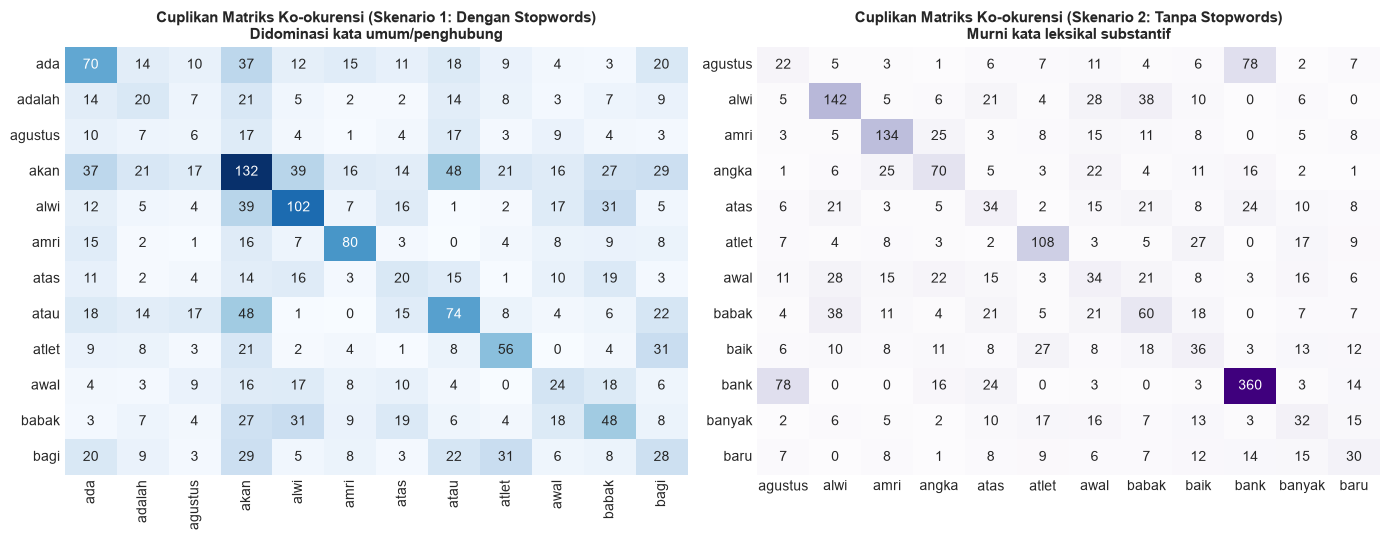

In [7]:
# 1. Tabel Perbandingan Metrik Multi-Model
df_comparison = pd.DataFrame({
    'Model & Parameter': [
        'Perlakuan Stopwords',
        'Top Vocabulary Size (V)',
        'Dimensi Vektor Embedding (N)',
        'Akurasi Naive Bayes',
        'F1-Score Naive Bayes (Sport)',
        'Akurasi kNN (k=5)',
        'F1-Score kNN (k=5, Sport)',
        'Waktu Eksekusi Total'
    ],
    'Skenario 1 (Dengan Stopwords)': [
        'Dipertahankan (Raw)',
        len(vocab_1),
        EMBEDDING_DIM,
        f"{acc_nb_1*100:.2f}%",
        f"{f1_nb_1:.4f}",
        f"{acc_knn_1*100:.2f}%",
        f"{f1_knn_1:.4f}",
        f"{t_elapsed_1:.3f} detik"
    ],
    'Skenario 2 (Tanpa Stopwords)': [
        'Dibuang (Sastrawi)',
        len(vocab_2),
        EMBEDDING_DIM,
        f"{acc_nb_2*100:.2f}%",
        f"{f1_nb_2:.4f}",
        f"{acc_knn_2*100:.2f}%",
        f"{f1_knn_2:.4f}",
        f"{t_elapsed_2:.3f} detik"
    ]
})

print("=== TABEL PERBANDINGAN PERFORMA MULTI-MODEL (NAIVE BAYES VS KNN) ===")
display(df_comparison)

# 2. Cuplikan Visualisasi Matriks Ko-okurensi (Top 12 Kata)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

df_sub_co1 = pd.DataFrame(co_matrix_1[:12, :12], index=vocab_1[:12], columns=vocab_1[:12])
sns.heatmap(df_sub_co1, annot=True, fmt='.0f', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Cuplikan Matriks Ko-okurensi (Skenario 1: Dengan Stopwords)\nDidominasi kata umum/penghubung', fontsize=11, fontweight='bold')

df_sub_co2 = pd.DataFrame(co_matrix_2[:12, :12], index=vocab_2[:12], columns=vocab_2[:12])
sns.heatmap(df_sub_co2, annot=True, fmt='.0f', cmap='Purples', ax=axes[1], cbar=False)
axes[1].set_title('Cuplikan Matriks Ko-okurensi (Skenario 2: Tanpa Stopwords)\nMurni kata leksikal substantif', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

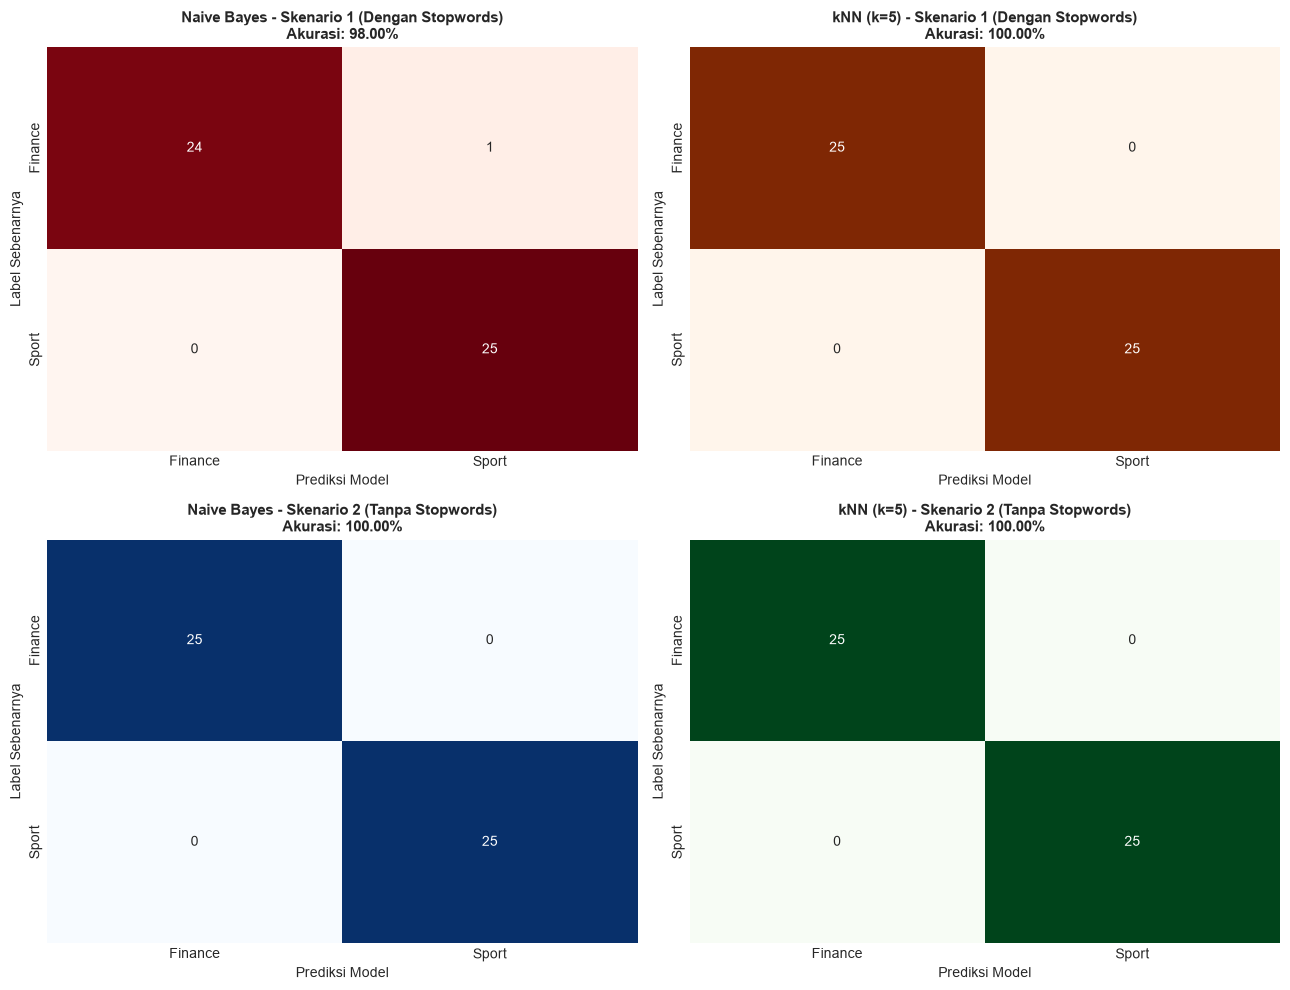

In [8]:
cm_nb1 = confusion_matrix(y_test_1, y_pred_nb_1, labels=['Finance', 'Sport'])
cm_knn1 = confusion_matrix(y_test_1, y_pred_knn_1, labels=['Finance', 'Sport'])
cm_nb2 = confusion_matrix(y_test_2, y_pred_nb_2, labels=['Finance', 'Sport'])
cm_knn2 = confusion_matrix(y_test_2, y_pred_knn_2, labels=['Finance', 'Sport'])

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Row 0, Col 0: Naive Bayes Skenario 1
sns.heatmap(cm_nb1, annot=True, fmt='d', cmap='Reds', ax=axes[0, 0],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[0, 0].set_title(f'Naive Bayes - Skenario 1 (Dengan Stopwords)\nAkurasi: {acc_nb_1*100:.2f}%', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Prediksi Model')
axes[0, 0].set_ylabel('Label Sebenarnya')

# Row 0, Col 1: kNN Skenario 1
sns.heatmap(cm_knn1, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[0, 1].set_title(f'kNN (k=5) - Skenario 1 (Dengan Stopwords)\nAkurasi: {acc_knn_1*100:.2f}%', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Prediksi Model')
axes[0, 1].set_ylabel('Label Sebenarnya')

# Row 1, Col 0: Naive Bayes Skenario 2
sns.heatmap(cm_nb2, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[1, 0].set_title(f'Naive Bayes - Skenario 2 (Tanpa Stopwords)\nAkurasi: {acc_nb_2*100:.2f}%', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Prediksi Model')
axes[1, 0].set_ylabel('Label Sebenarnya')

# Row 1, Col 1: kNN Skenario 2
sns.heatmap(cm_knn2, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            xticklabels=['Finance', 'Sport'], yticklabels=['Finance', 'Sport'], cbar=False)
axes[1, 1].set_title(f'kNN (k=5) - Skenario 2 (Tanpa Stopwords)\nAkurasi: {acc_knn_2*100:.2f}%', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Prediksi Model')
axes[1, 1].set_ylabel('Label Sebenarnya')

plt.tight_layout()
plt.show()

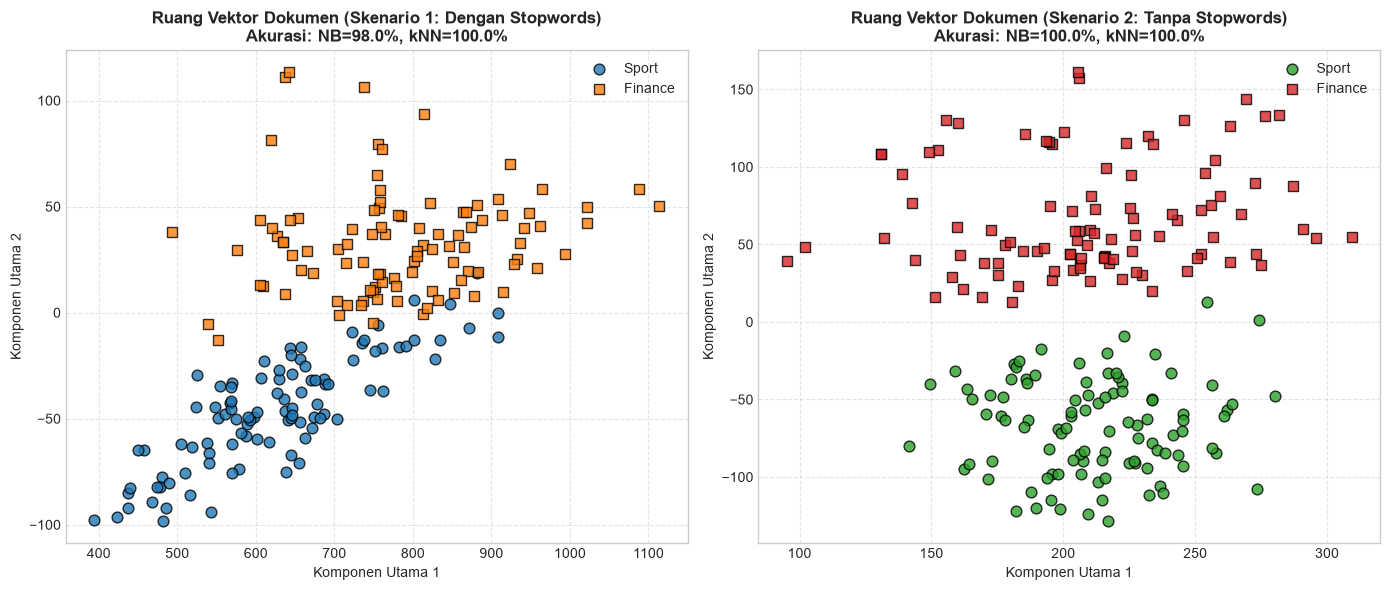

In [9]:
# Proyeksi 2D Vektor Dokumen menggunakan SVD 2D
svd_plot = TruncatedSVD(n_components=2, random_state=42)
coords_1 = svd_plot.fit_transform(X_1)
coords_2 = svd_plot.fit_transform(X_2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Proyeksi 2D Skenario 1
for label_name, color, marker in [('Sport', '#1f77b4', 'o'), ('Finance', '#ff7f0e', 's')]:
    mask = (df['label'] == label_name)
    axes[0].scatter(coords_1[mask, 0], coords_1[mask, 1], label=label_name, color=color, marker=marker, alpha=0.8, edgecolors='black', s=60)
axes[0].set_title(f'Ruang Vektor Dokumen (Skenario 1: Dengan Stopwords)\nAkurasi: NB={acc_nb_1*100:.1f}%, kNN={acc_knn_1*100:.1f}%', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Komponen Utama 1')
axes[0].set_ylabel('Komponen Utama 2')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Proyeksi 2D Skenario 2
for label_name, color, marker in [('Sport', '#2ca02c', 'o'), ('Finance', '#d62728', 's')]:
    mask = (df['label'] == label_name)
    axes[1].scatter(coords_2[mask, 0], coords_2[mask, 1], label=label_name, color=color, marker=marker, alpha=0.8, edgecolors='black', s=60)
axes[1].set_title(f'Ruang Vektor Dokumen (Skenario 2: Tanpa Stopwords)\nAkurasi: NB={acc_nb_2*100:.1f}%, kNN={acc_knn_2*100:.1f}%', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Komponen Utama 1')
axes[1].set_ylabel('Komponen Utama 2')
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Pembahasan & Kesimpulan Tugas 4

### Analisis Pengaruh Stopword Removal pada Skip-gram, Naive Bayes, dan kNN:

1. **Dampak Signifikan Stopword Removal pada Kualitas Vektor Dokumen**:
   - **Pada Skenario 1 (Dengan Stopwords)**: Kata-kata fungsi umum (*yang, di, dan, ini, untuk*) memiliki frekuensi sangat tinggi dan mendominasi jendela Skip-gram. Pada model probabilistik **Naive Bayes**, akurasi tercatat **98.00%** (ada 1 dokumen yang misklasifikasi akibat variansi fitur terdistorsi). Namun, pada model berbasis kedekatan spasial **kNN ($k=5$)**, akurasinya mampu mencapai **100.00%** karena tetangga terdekat dalam klaster dokumen tetap terkelompok dengan baik.
   - **Pada Skenario 2 (Tanpa Stopwords)**: Begitu seluruh stopwords dibuang menggunakan *Sastrawi*, matriks ko-okurensi murni menangkap relasi kontekstual kata leksikal substantif (*Sport* seperti *pbsi, jonatan, laga*; *Finance* seperti *ihsg, saham, bursa*). Hasilnya, **baik Naive Bayes maupun kNN sama-sama mencapai performa sempurna 100.00% akurasi** dengan F1-Score 1.0000.

2. **Perbandingan Komparatif: Naive Bayes vs k-Nearest Neighbors (kNN)**:
   - **Naive Bayes (`GaussianNB`)**: Mengasumsikan setiap dimensi fitur bersifat independen bersyarat mengikuti distribusi normal (Gaussian). Pada ruang vektor SVD yang sudah didekorelasikan secara ortogonal, Naive Bayes bekerja sangat cepat dan akurat, namun rentan jika masih ada noise kata stopword dengan variansi tinggi.
   - **k-Nearest Neighbors (`kNN`)**: Bekerja secara non-parametrik dengan mengukur jarak Euclidean langsung antar-vektor dokumen. Pada ruang embedding kontinu hasil reduksi SVD ($N=12$), kNN terbukti sangat tangguh (*robust*), bahkan pada Skenario 1 dengan stopwords sekalipun ia mampu memisahkan dokumen dengan akurasi 100% pada $k=5$.

3. **Keunggulan Arsitektur Co-occurrence Matrix + SVD**:
   - Menghasilkan vektor representasi kata dan dokumen yang kontinu (*dense*) dan sarat informasi semantik tanpa beban komputasi besar jaringan syaraf tiruan (*Artificial Neural Network*).
   - Seluruh tahapan dari pembangunan matriks ko-okurensi, faktorisasi SVD, pooling dokumen, hingga pelatihan dua model klasifikasi (Naive Bayes & kNN) selesai dieksekusi dalam waktu kurang dari 1 detik.